# Pipeline Demonstration: Single-Subject Brain Measure Calculations

This notebook provides a local demo of the MRI processing pipeline. While the full-scale analysis for this project was executed across 54 parallelized jobs on a High-Performance Computing (HPC) cluster, this demo serves as a "proof of concept" by walking through the computational workflow for a single exemplary subject using real MRI data from the HCP-YA release. <br> Additionally, the notebook contains visualizations of the functional connectivity transformation process (estimation, setting negative weights to zero, thresholding), as presented on the research poster. <br>
At the conclusion of this notebook, the resulting subject-level data is comparable to the output generated by the `fc_measures.py` script used on the cluster. From this point, the subsequent AUC-integration and data-cleaning steps must be performed before the metrics are suitable for SEM; these final processing stages can be traced and replicated in the `aggregate_fc_results.ipynb` notebook located in the `high_performance_cluster` directory.

### Workflow Demonstration

In [ ]:
# Set-Up
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import TqdmExperimentalWarning
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from comet import cifti, connectivity, graph
np.random.seed(42)

# Paths 
# IMPORTANT: Update MRI_BASE_DIR: Path to the neuroimaging data; must contain subject-named folders (e.g., 'SUBJ_ID/').
MRI_BASE_DIR = "/YOUR/PATH/TO/MRI/RESTINGSTATE/DATA"
MRI_REL_PATH = "MNINonLinear/Results/rfMRI_REST/rfMRI_REST_Atlas_MSMAll_hp2000_clean_rclean_tclean.dtseries.nii"

# Atlas parameters
N_TIMEPOINTS = 4800
CORTICAL_RES = 200
SUBCORTICAL_RES = 54
ATLAS_NAME = f"schaefer_{CORTICAL_RES}_cortical"
N_PARCELS = CORTICAL_RES + SUBCORTICAL_RES if "subcortical" in ATLAS_NAME else CORTICAL_RES

# Analysis parameters
DENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5]
WINDOWSIZE = 83 # 60/0.72
STEPSIZE = 10
EPSILON = 0.01 # torelance needed to account for rounding errors

# Subject for demonstration (the ID was erased after running the notebook)
# IMPORTANT: Insert a valid Subject ID
subject_list = ['XXXXXX']

In [2]:
# Pre-allocate result arrays
static_measures = np.full((len(subject_list), 30), np.nan) # 6 metrics * 5 densities
dynamic_measures = np.full((len(subject_list), 7), np.nan) # 1 metric * 5 densities + 2 metrics

# Loop over subjects, parcellate and calculate FC brain measures
for i, subject in enumerate(subject_list):
    file_path = f"{MRI_BASE_DIR}/{subject}/{MRI_REL_PATH}" 

    try:
        # Check for missing cifti data
        if not os.path.exists(file_path):
            print(f"MISSING: {file_path}")
            continue

        # Load data and parcellate
        cifti_data = nib.load(file_path).get_fdata(dtype='float32')
        timeseries = cifti.parcellate(cifti_data, atlas=ATLAS_NAME, standardize=True)
        
        # Skip subject if it contains ANY nan
        if np.isnan(timeseries).any(): 
            print(f"CONTAINED NAN: {file_path}")
            continue

        # Calculate static FC
        sFC = connectivity.Static_Pearson(timeseries, diagonal=0, fisher_z=True).estimate()
        sFC_noneg = graph.handle_negative_weights(sFC, type="discard")

        # Loop over densitiy range and calculate static measures dependent on thresholded FC matrices
        for j, dens in enumerate(DENSITIES):  
            sFC_thresh = graph.threshold(sFC_noneg, type="density", density=dens)

            static_measures[i,j] = graph.efficiency(sFC_thresh, local=False) # Static Global Efficiency
            static_measures[i,j+5] = graph.small_world_propensity(sFC_thresh)[0] # Static Small-World-Propensity
            static_measures[i,j+10] = graph.avg_clustering_onella(sFC_thresh) # Static Mean Clustering Coefficient
            static_measures[i,j+15] = np.mean(np.sum(sFC_thresh, axis=0)) # Static Global Strength
            static_measures[i,j+20] = np.mean(graph.betweenness(sFC_thresh)) # Static Betweenness Centrality
            static_measures[i,j+25] = np.mean(graph.participation_coef(sFC_thresh, ci="louvain", degree="undirected")) # Static Participation Coefficient

        dynamic_measures[i,0] = np.mean(np.std(timeseries, axis=0)) # Dynamic Mean BOLD Variability
            

        # Calculate dynamic FC
        sw = connectivity.SlidingWindow(timeseries, windowsize=WINDOWSIZE, stepsize=STEPSIZE, shape="gaussian", fisher_z=True)
        dFC = sw.estimate() 
        dFC_noneg = graph.handle_negative_weights(dFC, type="discard")

        # Loop over densitiy range and calculate dynamic global eff dependent on thresholded FC matrices
        for j, dens in enumerate(DENSITIES):  
            dFC_thresh = graph.threshold(dFC_noneg, type="density", density=dens)
            
            # density check
            actual_densities = graph.density_und(dFC_thresh)[0]
            if np.any(actual_densities < (dens - EPSILON)): # warning if ANY window is below the desired density
                min_dens = np.min(actual_densities)
                bad_count = np.sum(actual_densities < (dens - EPSILON))
                total_windows = actual_densities.shape[0]    
                print(f"WARNING: Subject {subject}, Target {dens}: "
                        f"{bad_count}/{total_windows} windows dropped below target density. "
                        f"Lowest density found: {min_dens:.3f}")


            # Global Efficiency Variability
            dynamic_efficiency = []
            num_windows = dFC_thresh.shape[2] # loop through 3rd dimension
            for t in range(num_windows):
                window_matrix = dFC_thresh[:,:,t]
                eff = graph.efficiency(window_matrix, local=False)
                dynamic_efficiency.append(eff)
            efficiency_var = np.std(dynamic_efficiency)
            dynamic_measures[i,1+j] = efficiency_var


        # Mean Edge Variability
        triu_indices = np.triu_indices(n=N_PARCELS, k=1)
        edge_time_series = dFC[triu_indices[0], triu_indices[1], :] 
        edge_variability = np.std(edge_time_series, axis=1) # multiple edge variabilities
        mean_edge_variability = np.mean(edge_variability) # scalar: global fluidity score over all edges
        dynamic_measures[i,6] = mean_edge_variability
    
    except Exception as e:
        print(f"ERROR: Could not calculate measures {file_path} for subject {subject}. Exception: {e}")

print(static_measures)
print(dynamic_measures)
print("Successfully constructed result arrays")

[[1.45867065e-01 1.64524307e-01 1.69228446e-01 1.70039640e-01
  1.70040567e-01 8.01393244e-01 7.58666799e-01 7.36810229e-01
  7.39867016e-01 7.52986855e-01 2.02881435e-01 1.60898900e-01
  1.35539447e-01 1.13290447e-01 9.46577381e-02 8.45675200e+00
  1.27516004e+01 1.54792576e+01 1.70599852e+01 1.78305077e+01
  2.69100000e+02 2.19370000e+02 1.99510000e+02 1.88680000e+02
  2.22500000e+02 1.82584399e-01 3.06565482e-01 3.94456332e-01
  4.49899592e-01 4.84778450e-01]]
[[0.29765764 0.00969211 0.01752174 0.01904386 0.01911425 0.01911454
  0.22341323]]
Successfully constructed result arrays


### Visualizations of Functional Connectivity Matrices

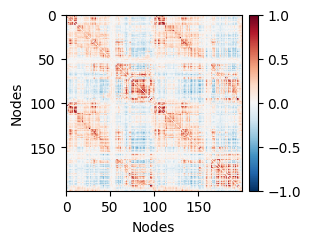

In [6]:
# sFC matrix (raw)
fig, ax = plt.subplots(figsize=(3, 3), layout="constrained")
ax.grid(False)
im = ax.imshow(sFC, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
ax.set_xlabel("Nodes", fontsize=10)
ax.set_ylabel("Nodes", fontsize=10)

plt.savefig('sFC.png', dpi=300)
plt.show()

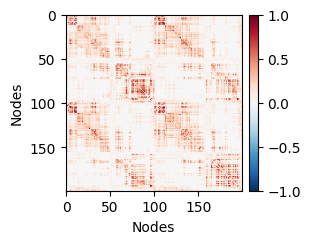

In [7]:
# sFC with negative edges set to 0
fig, ax = plt.subplots(figsize=(3, 3), layout="constrained")
ax.grid(False)
im = ax.imshow(sFC_noneg, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
ax.set_xlabel("Nodes", fontsize=10)
ax.set_ylabel("Nodes", fontsize=10)

plt.savefig('sFC_noneg.png', dpi=300)
plt.show()

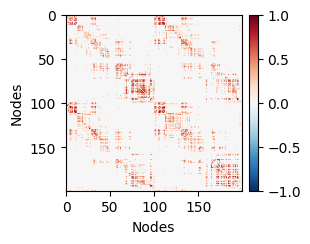

In [8]:
# sFC thresholded (shown for density 0.1)
sFC_thresh_first = graph.threshold(sFC_noneg, type="density", density=DENSITIES[0])# density 0.1

fig, ax = plt.subplots(figsize=(3, 3), layout="constrained")
ax.grid(False)
im = ax.imshow(sFC_thresh_first, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
ax.set_xlabel("Nodes", fontsize=10)
ax.set_ylabel("Nodes", fontsize=10)

plt.savefig('sFC_thresh.png', dpi=300)
plt.show()